# Comparación de Condiciones

El dataset escogido es sobre precios de casas en EEUU. Se propone la comparación de la variable pies cuadrados de terreno con precio de la casa.

In [22]:
import os
from pathlib import Path
from functools import cache

import kagglehub
import pandas as pd


def get_cache_dir() -> Path:
    """
    Creates and returns the cache directory for kagglehub.
    """
    cache_dir = Path.cwd() / "data" / "raw"
    cache_dir.mkdir(parents=True, exist_ok=True)

    os.environ["KAGGLEHUB_CACHE"] = str(cache_dir)

    return cache_dir


@cache
def get_data() -> pd.DataFrame:
    """
    Downloads the dataset from Kaggle and loads it into a DataFrame.
    """

    print("Cache directory:", get_cache_dir())

    data_path = kagglehub.dataset_download(
        "debayank2024/house-price-prediction"
    )

    file_path = Path(data_path) / "modified_data.csv"

    df = pd.read_csv(file_path)

    print("Path to file:", file_path)

    return df

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine import *

df = get_data()

Cache directory: /var/mnt/Shared/SharedDev/Experimentos_TempName/AC4-Comparacion-Condiciones/data/raw
Path to file: /var/mnt/Shared/SharedDev/Experimentos_TempName/AC4-Comparacion-Condiciones/data/raw/datasets/debayank2024/house-price-prediction/versions/1/modified_data.csv


### División del dataset por tamaño de vivienda

Con el fin de poder realizar la prueba t, se decidió dividir las viviendas utilizando la mediana de la variable sqft_living como punto de división, categorizando entonces las viviendas en "casas pequeñas" y "casas grandes".

Casas pequeñas:
              price     bedrooms    bathrooms  sqft_living       sqft_lot  \
count  2.298000e+03  2298.000000  2298.000000  2298.000000    2298.000000   
mean   3.931081e+05     2.924717     1.703547  1430.236292    9984.698869   
std    5.715299e+05     0.720970     0.602781   342.237704   23123.427623   
min    0.000000e+00     1.000000     0.750000   370.000000     638.000000   
25%    2.650000e+05     3.000000     1.000000  1180.000000    4160.000000   
50%    3.600000e+05     3.000000     1.750000  1460.000000    7000.000000   
75%    4.717502e+05     3.000000     2.250000  1713.750000    9219.750000   
max    2.659000e+07     7.000000     4.250000  1970.000000  435600.000000   

            floors   waterfront         view    condition   sqft_above  \
count  2298.000000  2298.000000  2298.000000  2298.000000  2298.000000   
mean      1.357050     0.002611     0.088338     3.476066  1268.862924   
std       0.543209     0.051042     0.448024     0.688605   330.5377

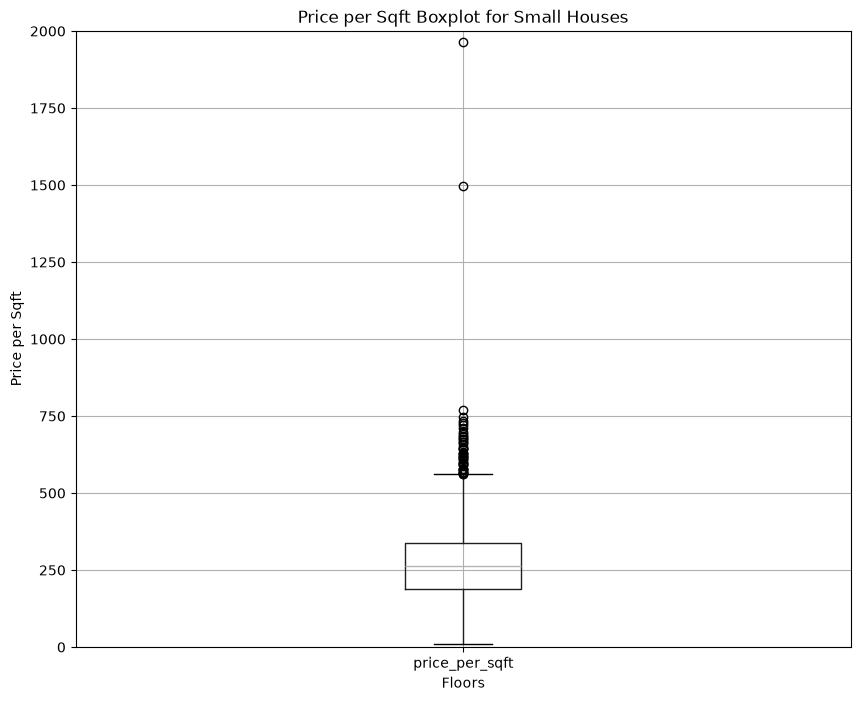

In [29]:
# Mediana de sqft_living
import matplotlib


mediana_sqft = df['sqft_living'].median()

# División en dos dataframes: casas pequeñas y casas grandes
casas_pequenas = df[df['sqft_living'] < mediana_sqft].copy()
casas_grandes = df[df['sqft_living'] >= mediana_sqft].copy()

print("Casas pequeñas:")
print(casas_pequenas.describe())
print("Casas grandes:")
print(casas_grandes.describe())


print(casas_pequenas['price_per_sqft'].sort_values(ascending=False).head(10))
print(casas_grandes['price_per_sqft'].sort_values(ascending=False).head(10))

# También revisa los ceros
print((casas_pequenas['price_per_sqft'] == 0).sum())
print((casas_grandes['price_per_sqft'] == 0).sum())

casas_pequenas = casas_pequenas[casas_pequenas['price_per_sqft'] > 0]
casas_grandes = casas_grandes[casas_grandes['price_per_sqft'] > 0]

#boxplot of price per sqft by number of floors
casas_pequenas.boxplot(column='price_per_sqft', grid=True, figsize=(10, 8))
plt.title('Price per Sqft Boxplot for Small Houses')
plt.xlabel('Floors')
plt.ylim(0, 2000)
plt.ylabel('Price per Sqft')
plt.show()


### Prueba de normalidad

Se utiliza la prueba de Shapiro-Wilk para verificar la normalidad de `price_per_sqft` en ambos grupos.

**H0:** Los datos siguen una distribución normal.  
**H1:** Los datos no siguen una distribución normal.


Casas pequeñas - W: 0.0934, p-valor: 0.000000
Casas grandes - W: 0.4590, p-valor: 0.000000


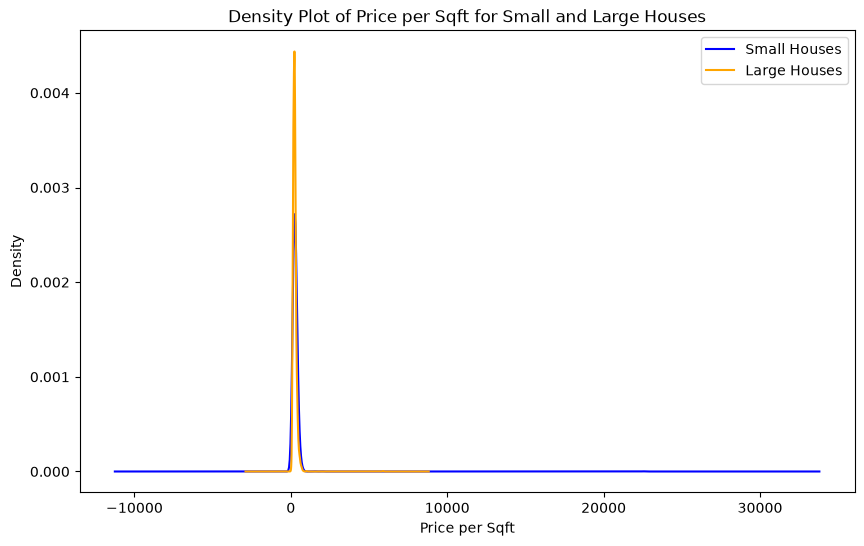

In [59]:
from scipy import stats

variable = 'price_per_sqft'

stat_pequenas, p_pequenas = stats.shapiro(casas_pequenas[variable].dropna())
stat_grandes, p_grandes = stats.shapiro(casas_grandes[variable].dropna())

print(f"Casas pequeñas - W: {stat_pequenas:.4f}, p-valor: {p_pequenas:f}")
print(f"Casas grandes - W: {stat_grandes:.4f}, p-valor: {p_grandes:f}")

# density plot of price per sqft for small and large houses
plt.figure(figsize=(10, 6))
plt.title('Density Plot of Price per Sqft for Small and Large Houses')
casas_pequenas[variable].plot(kind='density', label='Small Houses', color='blue')
casas_grandes[variable].plot(kind='density', label='Large Houses', color='orange')
plt.xlabel('Price per Sqft')
plt.ylabel('Density')
plt.legend()
plt.show()

con un p-valor menor a 0.05, se rechaza la hipótesis nula H0, indicando que los datos no siguen una distribución normal.

Casas pequeñas (log) - W: 0.9788, p-valor: 0.0000
Casas grandes (log) - W: 0.9851, p-valor: 0.0000


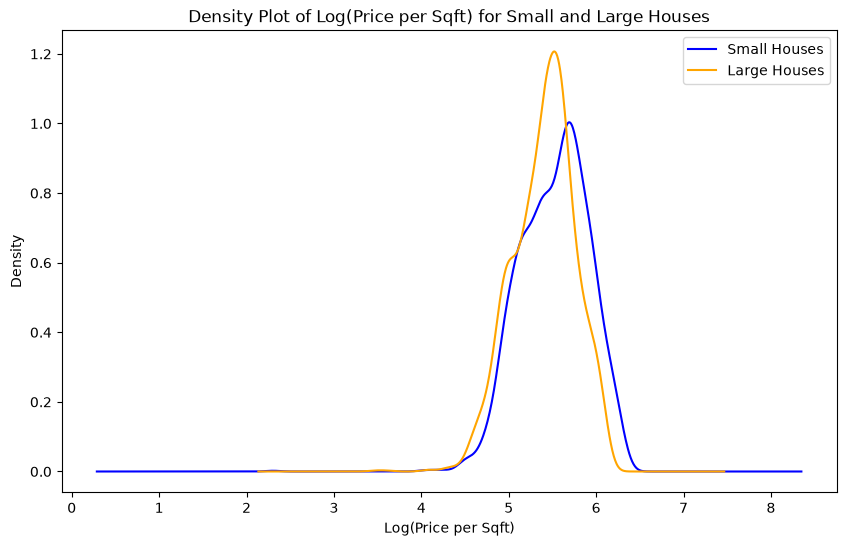

In [ ]:

# Log transformation of price_per_sqft and drop atipical values
Q1_pequenas = casas_pequenas[variable].quantile(0.25)
Q3_pequenas = casas_pequenas[variable].quantile(0.75)
IQR_pequenas = Q3_pequenas - Q1_pequenas
lower_bound_pequenas = Q1_pequenas - 1.5 * IQR_pequenas
upper_bound_pequenas = Q3_pequenas + 1.5 * IQR_pequenas
casas_pequenas = casas_pequenas[(casas_pequenas[variable] >= lower_bound_pequenas) & (casas_pequenas[variable] <= upper_bound_pequenas)]

Q1_grandes = casas_grandes[variable].quantile(0.25)
Q3_grandes = casas_grandes[variable].quantile(0.75)
IQR_grandes = Q3_grandes - Q1_grandes
lower_bound_grandes = Q1_grandes - 1.5 * IQR_grandes
upper_bound_grandes = Q3_grandes + 1.5 * IQR_grandes
casas_grandes = casas_grandes[(casas_grandes[variable] >= lower_bound_grandes) & (casas_grandes[variable] <= upper_bound_grandes)]

log_pequenas = np.log(casas_pequenas[variable].dropna())
log_grandes = np.log(casas_grandes[variable].dropna())


stat_log_pequenas, p_log_pequenas = stats.shapiro(log_pequenas)
stat_log_grandes, p_log_grandes = stats.shapiro(log_grandes)

print(f"Casas pequeñas (log) - W: {stat_log_pequenas:.4f}, p-valor: {p_log_pequenas:.4f}")
print(f"Casas grandes (log) - W: {stat_log_grandes:.4f}, p-valor: {p_log_grandes:.4f}")

# density plot of log(price_per_sqft) for small and large houses
plt.figure(figsize=(10, 6))
plt.title('Density Plot of Log(Price per Sqft) for Small and Large Houses')
log_pequenas.plot(kind='density', label='Small Houses', color='blue')
log_grandes.plot(kind='density', label='Large Houses', color='orange')
plt.xlabel('Log(Price per Sqft)')
plt.ylabel('Density')
plt.legend()
plt.show()


### Prueba de igualdad de varianzas (Brown-Forsythe)

Para verificar la hipótesis de igualdad de varianzas entre los grupos de casas pequeñas y casas 
grandes, se utilizó la prueba de Brown-Forsythe, modificación de la prueba de Levene que centra los grupos usando la mediana en vez de la media. La razón de utilizar esta prueba se debe a que en el EDA realizado anteriormente con el dataset se descubrieron multiples valores atípicos en la variable price_per_sqft. La hipótesis plantea que la varianza de ambos grupos son iguales.

In [26]:
from scipy import stats

variable = 'price_per_sqft'

stat, p_value = stats.levene(casas_pequenas[variable], casas_grandes[variable], center='median')

print(f"Estadístico de Brown-Forsythe: {stat:.4f}")
print(f"p-valor: {p_value:f}")

alpha = 0.05
if p_value < alpha:
    print("Se rechaza H0: las varianzas son diferentes")
else:
    print("No se rechaza H0: no hay diferencia entre las varianzas")

Estadístico de Brown-Forsythe: 4.3531
p-valor: 0.036998
Se rechaza H0: las varianzas son diferentes


Con un p-valor de 0.048598 (< 0.05), se rechaza H0: las varianzas de price_per_sqft entre 
casas pequeñas y casas grandes son significativamente diferentes, aunque es 
significativo por un margen pequeño. Con esto hecho, se debe proseguir con una prueba t de Welch.

### Prueba t

Como la prueba de Brown-Forsythe indicó varianzas diferentes, se utiliza la prueba t de Welch.

**H0:** Las medias de `price_per_sqft` son iguales en ambos grupos.  
**H1:** Las medias de `price_per_sqft` son diferentes entre los grupos.


In [27]:
stat_t, p_t = stats.ttest_ind(
    casas_pequenas[variable],
    casas_grandes[variable],
    equal_var=False,
    nan_policy='omit'
)

print(f"Estadístico t: {stat_t:.4f}")
print(f"p-valor: {p_t:f}")


Estadístico t: 3.4656
p-valor: 0.000537


## Conclusión

La prueba t de Welch indica que hay una diferencia significativa en las medias de `price_per_sqft` entre casas pequeñas y casas grandes, con un p-valor de 0.000000 (< 0.05). Esto sugiere que el tamaño de la vivienda tiene un efecto significativo en el precio por pie cuadrado.

              price    price_log
count  4.551000e+03  4551.000000
mean   5.579059e+05    13.064963
std    5.639299e+05     0.542789
min    7.800000e+03     8.961879
25%    3.262643e+05    12.695463
50%    4.650000e+05    13.049793
75%    6.575000e+05    13.396200
max    2.659000e+07    17.096046
              price    price_log
count  4.473000e+03  4473.000000
mean   5.264365e+05    13.049845
std    2.802407e+05     0.494522
min    1.150000e+05    11.652687
25%    3.261000e+05    12.694959
50%    4.620000e+05    13.043320
75%    6.500000e+05    13.384728
max    1.875000e+06    14.444119
Estadístico W: 0.9973
p-valor: 0.000000


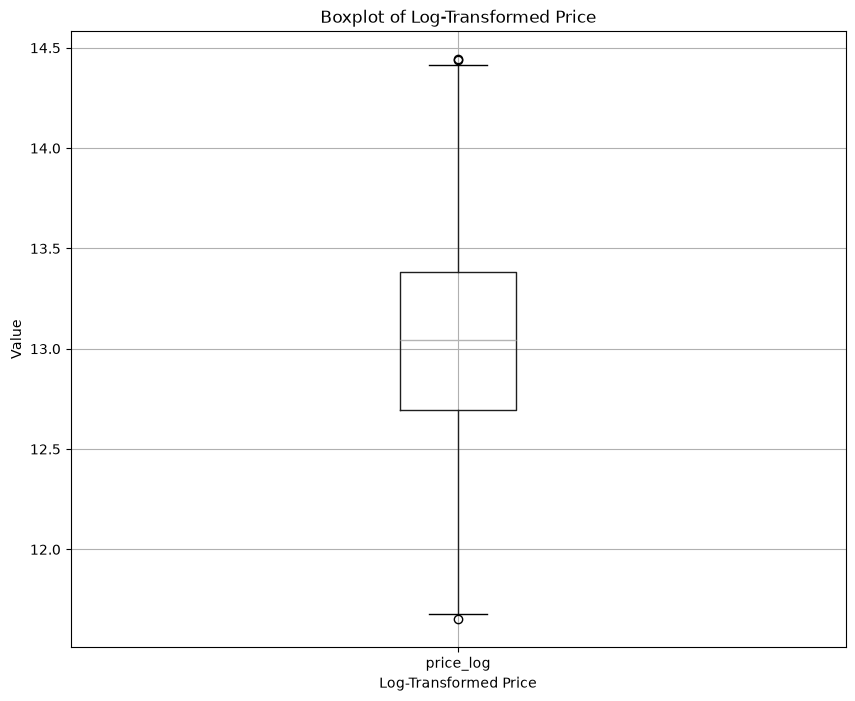

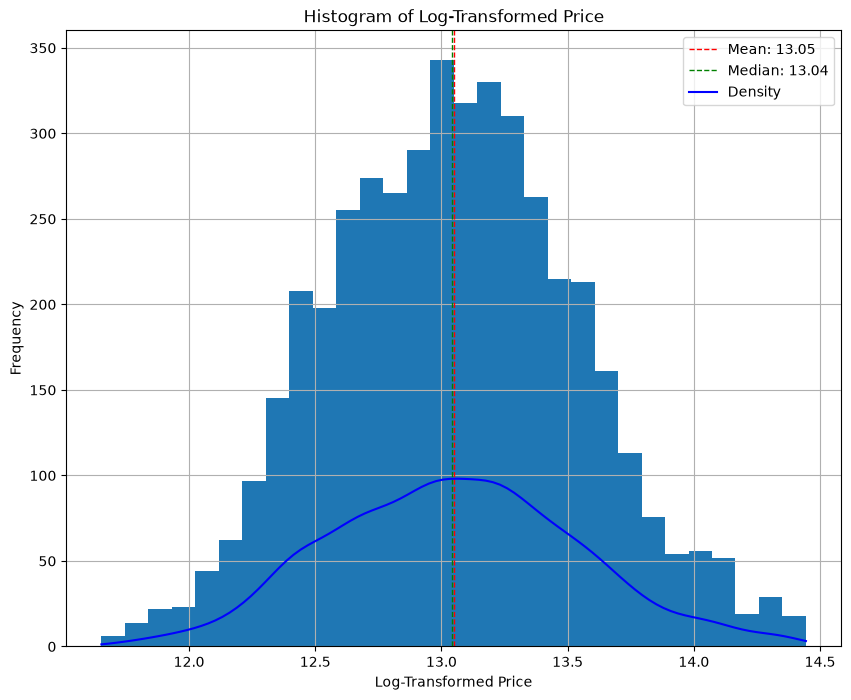

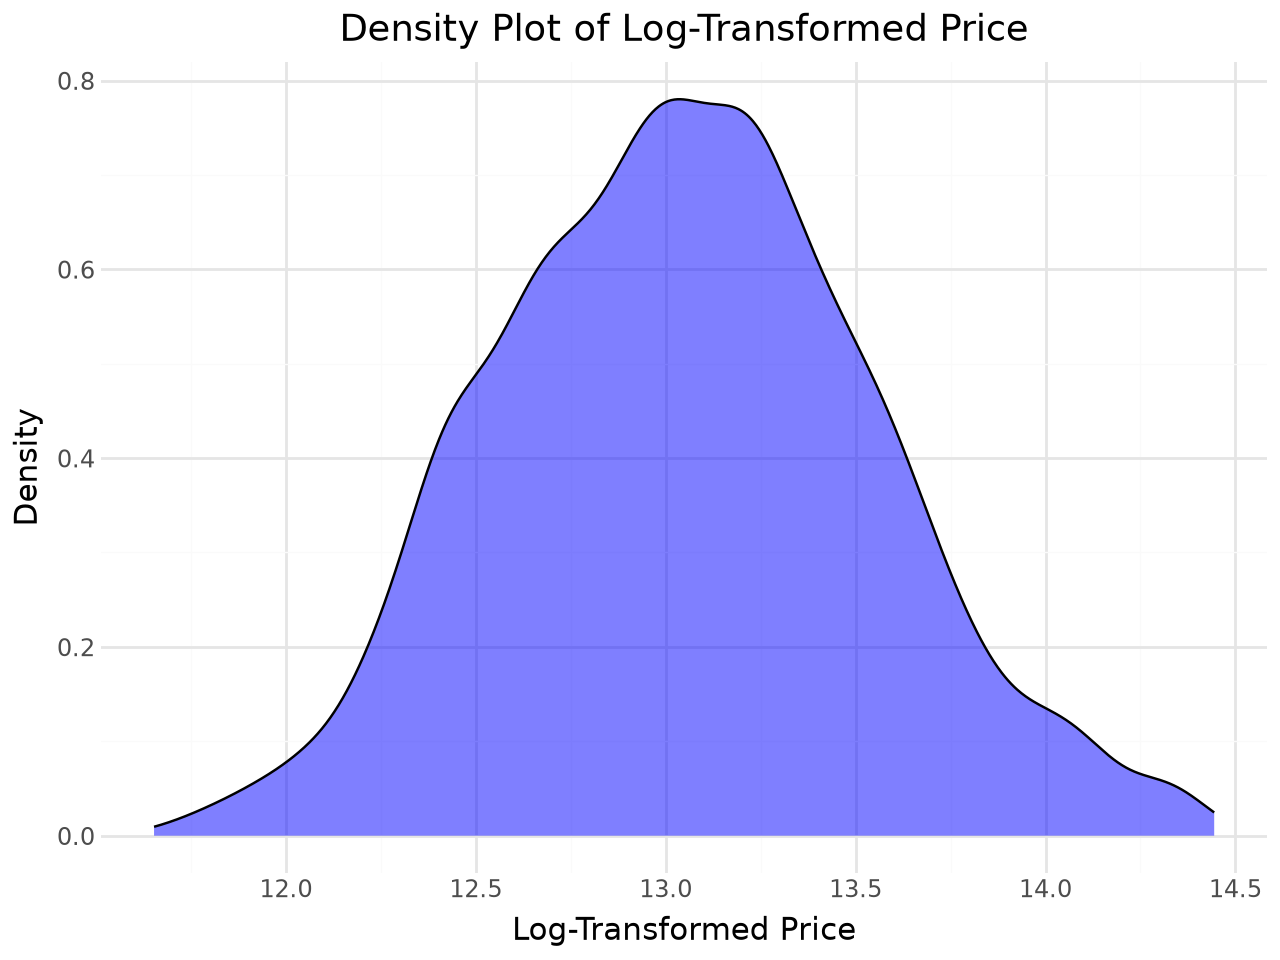

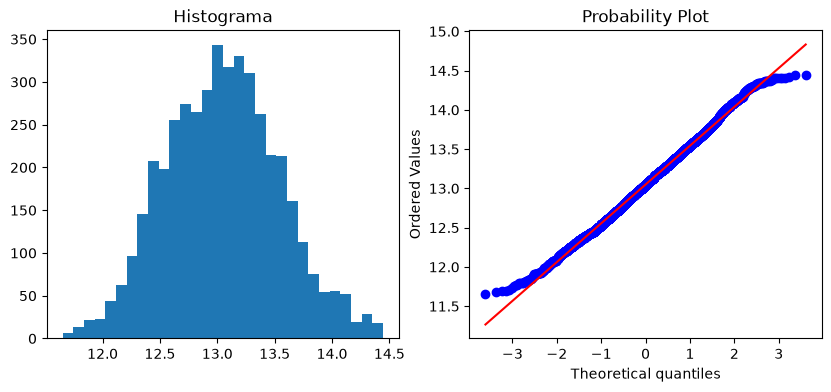

In [54]:
# transformación logarítmica del precio

price_df = df[df['price'] > 0][['price']].copy().dropna()
price_df['price_log'] = np.log(price_df['price'])

print(price_df.describe())

# eliminar valores atípicos en la columna 'price_log'
Q1 = price_df['price_log'].quantile(0.25)
Q3 = price_df['price_log'].quantile(0.75)
IQR = Q3 - Q1

price_df = price_df[~((price_df['price_log'] < (Q1 - 1.5 * IQR)) | (price_df['price_log'] > (Q3 + 1.5 * IQR)))]

print(price_df.describe())

stat, p_value = stats.shapiro(price_df['price_log'].dropna())

print(f"Estadístico W: {stat:.4f}")
print(f"p-valor: {p_value:f}")

price_df.boxplot(column='price_log', grid=True, figsize=(10, 8))
plt.title('Boxplot of Log-Transformed Price')
plt.xlabel('Log-Transformed Price')
plt.ylabel('Value')
plt.show()

price_df['price_log'].hist(bins=30, grid=True, figsize=(10, 8))
# add title and labels
plt.title('Histogram of Log-Transformed Price')
plt.xlabel('Log-Transformed Price')
plt.ylabel('Frequency')
# add line for mean and median
mean = price_df['price_log'].mean()
median = price_df['price_log'].median()
plt.axvline(mean, color='r', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.2f}')
plt.axvline(median, color='g', linestyle='dashed', linewidth=1, label=f'Median: {median:.2f}')
plt.legend()
# add density line to the histogram
density = stats.gaussian_kde(price_df['price_log'].dropna())
x = np.linspace(price_df['price_log'].min(), price_df['price_log'].max(), 100)
plt.plot(x, density(x) * len(price_df['price_log'].dropna()) * (x[1] - x[0]), color='blue', label='Density')
plt.legend()
plt.show()

# density plot
chart = (ggplot(price_df, aes(x='price_log')) +
 geom_density(fill='blue', alpha=0.5) +
 labs(title='Density Plot of Log-Transformed Price', x='Log-Transformed Price', y='Density') +
 theme_minimal())
chart.show()

import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(price_df['price_log'], bins=30)
axes[0].set_title('Histograma')
stats.probplot(price_df['price_log'], dist="norm", plot=axes[1])
plt.show()